In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Leads_Reales.csv', skiprows=2, thousands=',')
df.columns = [c.strip() for c in df.columns]

# Nos quedamos solo con las filas del reporte mensual (antes de la tabla resumen inferior)
df = df.iloc[0:29].copy()

# Eliminamos columnas vacías (generadas por comas sobrantes al final de cada fila)
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])
df = df.reset_index(drop=True)

df.head(15)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%
5,NaN,Junio,967,140,173,31,3,620,17,6,1.0%,64%
6,NaN,Julio,954,112,251,12,9,570,5,21,3.7%,60%
7,NaN,Agosto,"1,409",504,324,17,18,546,22,17,3.1%,39%
8,NaN,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%,40%
9,NaN,Octubre,"1,973",514,606,18,13,822,72,23,2.8%,42%


In [ ]:
df.info()
print('\nNulos por columna:')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   29 non-null     str    
 2   Total                 28 non-null     str    
 3   Ilocalizable          28 non-null     str    
 4   No Contesta           28 non-null     str    
 5   D. Incorrectos        28 non-null     str    
 6   Duplicados            28 non-null     str    
 7   Efectivos             28 non-null     str    
 8   Abiertos              28 non-null     str    
 9   Ventas                28 non-null     str    
 10  Conversion            28 non-null     str    
 11  Efectividad de Leads  28 non-null     str    
dtypes: float64(1), str(11)
memory usage: 2.8 KB

Nulos por columna:
Año                     26
Mes                      0
Total                    1
Ilocalizable             1
No Contesta      

Se hace la imputación de nulos y conversión a numérico


In [ ]:
df['Año'] = df['Año'].ffill().astype(int)
df['Año'].unique()

array([2024, 2025, 2026])

Se pasa la columna Mes de categórica a numérica

In [ ]:
meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4, 'Mayo': 5, 'Junio': 6,
    'Julio': 7, 'Agosto': 8, 'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

df['Mes'] = df['Mes'].str.strip().map(meses).astype(int)
df[['Año', 'Mes']].head(15)

,Año,Mes
0,2024,1
1,2024,2
2,2024,3
3,2024,4
4,2024,5
5,2024,6
6,2024,7
7,2024,8
8,2024,9
9,2024,10


Separadores de miles y porcentajes

In [ ]:
num_cols = ['Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
            'Duplicados', 'Efectivos', 'Abiertos', 'Ventas']
pct_cols = ['Conversion', 'Efectividad de Leads']

for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

for c in pct_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace('%', '', regex=False).str.strip(),
        errors='coerce'
    ) / 100

df.dtypes

Año                       int64
Mes                       int64
Total                   float64
Ilocalizable            float64
No Contesta             float64
D. Incorrectos          float64
Duplicados              float64
Efectivos               float64
Abiertos                float64
Ventas                  float64
Conversion              float64
Efectividad de Leads    float64
dtype: object

Los nulos restantes en columnas operativas


In [ ]:
metric_cols = num_cols + pct_cols
print('Nulos antes de imputar:', df[metric_cols].isna().sum().sum())

for c in metric_cols:
    df[c] = df[c].fillna(df[c].median())

print('Nulos después de imputar:', df[metric_cols].isna().sum().sum())
df.head(3)

Nulos antes de imputar: 10
Nulos después de imputar: 0


,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,1,1170.5,110.0,185.5,13.0,27.0,704.5,200.5,30.0,0.0405,0.64
1,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.0310,0.72
2,2024,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,0.0550,0.72


Detección de outliers (rango intercuartílico)


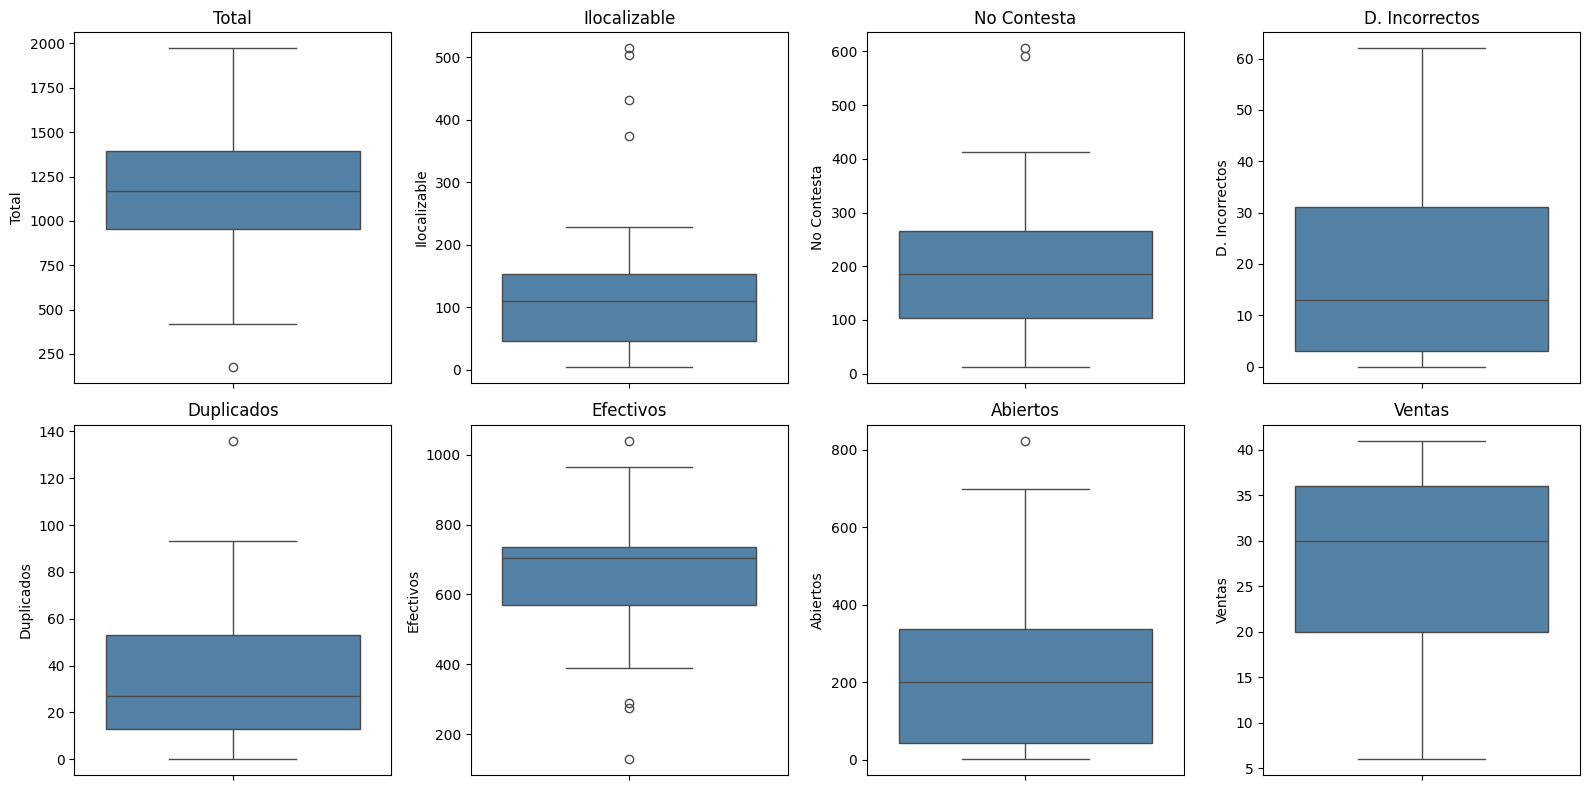

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, c in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[c], ax=ax, color='steelblue')
    ax.set_title(c)
plt.tight_layout()
plt.show()

In [ ]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf, limite_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return limite_inf, limite_sup

for c in num_cols:
    low, high = detectar_outliers_iqr(df[c])
    outliers = df[(df[c] < low) | (df[c] > high)]
    if len(outliers):
        print(f"{c}: {len(outliers)} outlier(s) -> " +
              ', '.join(f"{int(a)}-{int(m):02d}: {v:g}" for a, m, v in
                        outliers[['Año', 'Mes', c]].values))

Total: 1 outlier(s) -> 2024-03: 178
Ilocalizable: 4 outlier(s) -> 2024-08: 504, 2024-09: 431, 2024-10: 514, 2024-12: 374
No Contesta: 2 outlier(s) -> 2024-10: 606, 2025-08: 591
Duplicados: 1 outlier(s) -> 2025-01: 136
Efectivos: 4 outlier(s) -> 2024-03: 128, 2024-04: 288, 2024-05: 274, 2024-11: 1040
Abiertos: 1 outlier(s) -> 2025-12: 823


Los valores marcados se estan considerando como picos y valles reales del negocio, errores de captura, sino una tardanza de la misma, así que en vez de eliminarlos se acotan (winsorización) a los límites del IQR para reducir su influencia en análisis posteriores sin perder el registro del mes.

In [ ]:
for c in num_cols:
    low, high = detectar_outliers_iqr(df[c])
    df[c] = df[c].clip(lower=max(low, 0), upper=high)

df[num_cols].describe()

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,1128.551724,122.413793,202.431034,18.896552,32.827586,669.189655,246.982759,27.068966
std,405.321463,96.063230,135.475599,19.030699,29.227029,183.975077,228.460394,10.898660
min,295.500000,5.000000,13.000000,0.000000,0.000000,321.000000,1.000000,6.000000
25%,954.000000,46.000000,104.000000,3.000000,13.000000,570.000000,42.000000,20.000000
50%,1170.500000,110.000000,185.500000,13.000000,27.000000,704.500000,200.500000,30.000000
75%,1393.000000,153.000000,266.000000,31.000000,53.000000,736.000000,338.000000,36.000000
max,1973.000000,313.500000,509.000000,62.000000,113.000000,985.000000,782.000000,41.000000


In [ ]:
df.info()
print('\nNulos restantes:', df.isna().sum().sum())
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   29 non-null     int64  
 1   Mes                   29 non-null     int64  
 2   Total                 29 non-null     float64
 3   Ilocalizable          29 non-null     float64
 4   No Contesta           29 non-null     float64
 5   D. Incorrectos        29 non-null     float64
 6   Duplicados            29 non-null     float64
 7   Efectivos             29 non-null     float64
 8   Abiertos              29 non-null     float64
 9   Ventas                29 non-null     float64
 10  Conversion            29 non-null     float64
 11  Efectividad de Leads  29 non-null     float64
dtypes: float64(10), int64(2)
memory usage: 2.8 KB

Nulos restantes: 0


,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,1,1170.5,110.0,185.5,13.0,27.0,704.5,200.5,30.0,0.0405,0.64
1,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.0310,0.72
2,2024,3,295.5,37.0,13.0,0.0,0.0,321.0,1.0,7.0,0.0550,0.72
3,2024,4,416.0,79.0,46.0,3.0,0.0,321.0,1.0,8.0,0.0280,0.69
4,2024,5,422.0,33.0,100.0,17.0,0.0,321.0,5.0,13.0,0.0470,0.65
5,2024,6,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,0.0100,0.64
6,2024,7,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,0.0370,0.60
7,2024,8,1409.0,313.5,324.0,17.0,18.0,546.0,22.0,17.0,0.0310,0.39
8,2024,9,1315.0,313.5,314.0,14.0,26.0,530.0,42.0,17.0,0.0320,0.40
9,2024,10,1973.0,313.5,509.0,18.0,13.0,822.0,72.0,23.0,0.0280,0.42


Regresión Lineal Simple


<Axes: xlabel='Abiertos', ylabel='Ventas'>

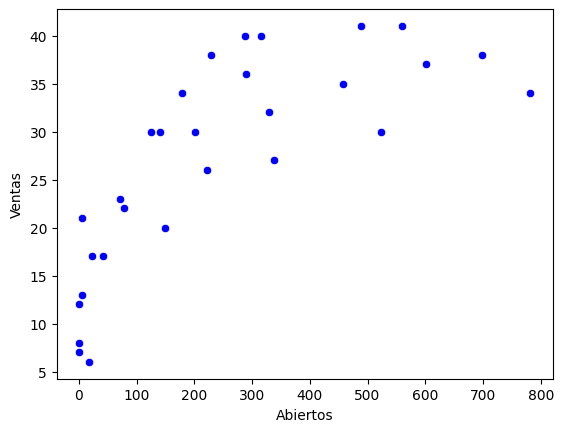

In [ ]:
#Imprimimos el scatter plot entre la variable dependiente (Ventas) e independiente (Abiertos)
#para observar el comportamiento en su dispersión
sns.scatterplot(x='Abiertos', y='Ventas', color="blue", data=df)

In [ ]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['Abiertos']]
Var_Dep= df['Ventas']

In [ ]:
%pip install scikit-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [ ]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abiertos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03608336]),
 'rank_': 1,
 'singular_': array([1208.89877218]),
 'intercept_': np.float64(18.1569969690421)}

In [ ]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5721233263972691

In [ ]:
#Predecimos los valores de Ventas a partir de la variable "Abiertos"
y_pred= model.predict(X=df[['Abiertos']])
y_pred

array([25.39171126, 18.19308033, 18.19308033, 18.19308033, 18.33741378,
       18.77041414, 18.33741378, 18.95083096, 19.67249822, 20.75499911,
       21.00758265, 30.06450678, 26.16750357, 23.56950143, 22.66741735,
       23.24475116, 24.61591896, 29.52325633, 28.62117226, 30.35317368,
       26.42008711, 28.54900553, 35.76567814, 46.37418688, 39.87918153,
       37.02859585, 43.34318438, 38.32759692, 34.68317725])

In [ ]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(0, 'Predicciones', y_pred)
df

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,25.391711,2024,1,1170.5,110.0,185.5,13.0,27.0,704.5,200.5,30.0,0.0405,0.64
1,18.193080,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.0310,0.72
2,18.193080,2024,3,295.5,37.0,13.0,0.0,0.0,321.0,1.0,7.0,0.0550,0.72
3,18.193080,2024,4,416.0,79.0,46.0,3.0,0.0,321.0,1.0,8.0,0.0280,0.69
4,18.337414,2024,5,422.0,33.0,100.0,17.0,0.0,321.0,5.0,13.0,0.0470,0.65
5,18.770414,2024,6,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,0.0100,0.64
6,18.337414,2024,7,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,0.0370,0.60
7,18.950831,2024,8,1409.0,313.5,324.0,17.0,18.0,546.0,22.0,17.0,0.0310,0.39
8,19.672498,2024,9,1315.0,313.5,314.0,14.0,26.0,530.0,42.0,17.0,0.0320,0.40
9,20.754999,2024,10,1973.0,313.5,509.0,18.0,13.0,822.0,72.0,23.0,0.0280,0.42


<Axes: xlabel='Abiertos', ylabel='Ventas'>

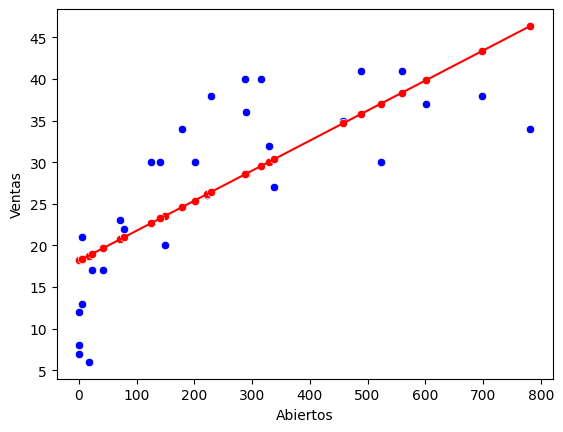

In [ ]:
#Visualizamos la gráfica comparativa entre las Ventas reales y las Ventas predichas

sns.scatterplot(x='Abiertos', y='Ventas', color="blue", data=df)
sns.scatterplot(x='Abiertos', y='Predicciones', color="red", data=df)
sns.lineplot(x='Abiertos', y='Predicciones', color="red", data=df)

In [ ]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.5721233263972691

In [ ]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.7563883436418551)

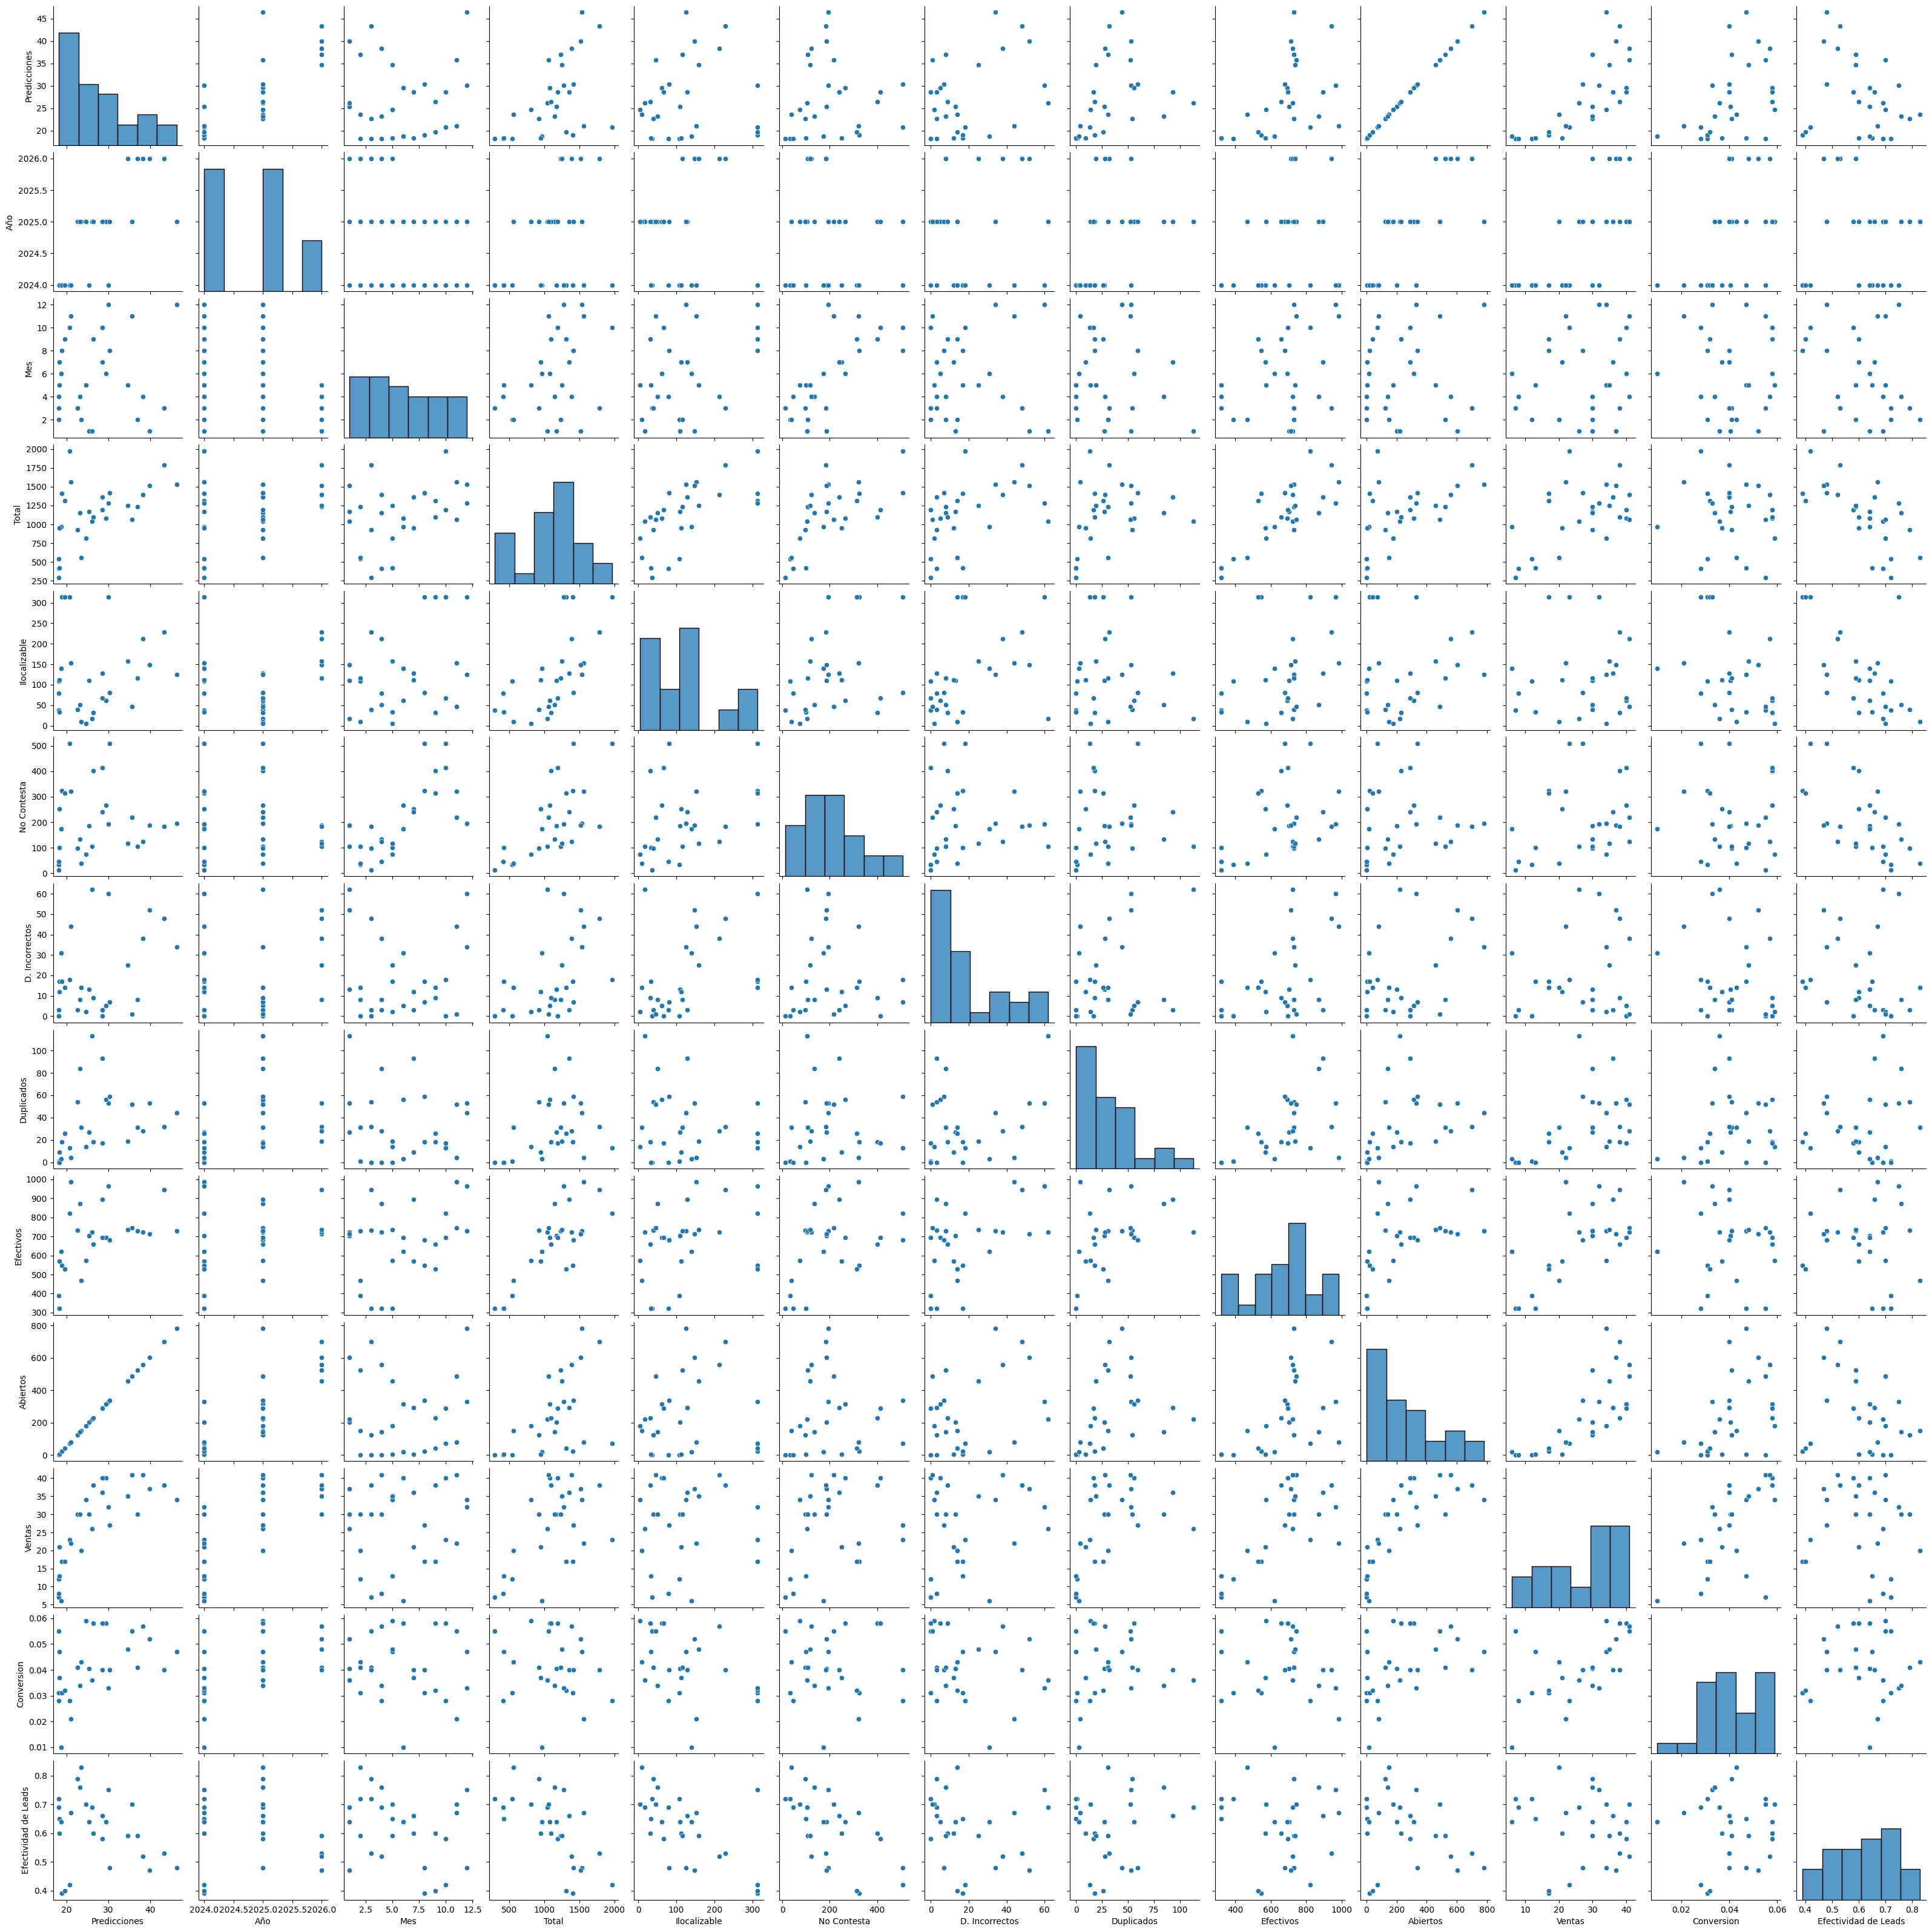

In [ ]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df)

In [ ]:
#Encontramos todas las correlaciones entre las variables
Corr_Factors=df.corr()
Corr_Factors

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
Predicciones,1.000000,0.801944,0.052487,0.529541,0.090297,0.028276,0.384647,0.372332,0.515138,1.000000,0.756388,0.449857,-0.279860
Año,0.801944,1.000000,-0.298181,0.330175,-0.154403,-0.117463,0.188504,0.394608,0.377465,0.801944,0.720050,0.528407,-0.111159
Mes,0.052487,-0.298181,1.000000,0.396916,0.367866,0.654698,0.016901,-0.091511,0.323457,0.052487,0.164097,-0.070550,-0.301703
Total,0.529541,0.330175,0.396916,1.000000,0.637501,0.650089,0.450678,0.282128,0.794280,0.529541,0.527787,-0.125384,-0.657941
Ilocalizable,0.090297,-0.154403,0.367866,0.637501,1.000000,0.376283,0.407647,-0.137875,0.331108,0.090297,-0.036784,-0.416688,-0.631656
No Contesta,0.028276,-0.117463,0.654698,0.650089,0.376283,1.000000,-0.027853,0.035846,0.381624,0.028276,0.252785,-0.067267,-0.613550
D. Incorrectos,0.384647,0.188504,0.016901,0.450678,0.407647,-0.027853,1.000000,0.249487,0.468553,0.384647,0.140372,-0.245999,-0.179278
Duplicados,0.372332,0.394608,-0.091511,0.282128,-0.137875,0.035846,0.249487,1.000000,0.512516,0.372332,0.488547,0.105834,0.132272
Efectivos,0.515138,0.377465,0.323457,0.794280,0.331108,0.381624,0.468553,0.512516,1.000000,0.515138,0.655088,-0.099377,-0.094090
Abiertos,1.000000,0.801944,0.052487,0.529541,0.090297,0.028276,0.384647,0.372332,0.515138,1.000000,0.756388,0.449857,-0.279860


In [ ]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Predicciones,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
Predicciones,1.000000,0.801944,0.052487,0.529541,0.090297,0.028276,0.384647,0.372332,0.515138,1.000000,0.756388,0.449857,0.279860
Año,0.801944,1.000000,0.298181,0.330175,0.154403,0.117463,0.188504,0.394608,0.377465,0.801944,0.720050,0.528407,0.111159
Mes,0.052487,0.298181,1.000000,0.396916,0.367866,0.654698,0.016901,0.091511,0.323457,0.052487,0.164097,0.070550,0.301703
Total,0.529541,0.330175,0.396916,1.000000,0.637501,0.650089,0.450678,0.282128,0.794280,0.529541,0.527787,0.125384,0.657941
Ilocalizable,0.090297,0.154403,0.367866,0.637501,1.000000,0.376283,0.407647,0.137875,0.331108,0.090297,0.036784,0.416688,0.631656
No Contesta,0.028276,0.117463,0.654698,0.650089,0.376283,1.000000,0.027853,0.035846,0.381624,0.028276,0.252785,0.067267,0.613550
D. Incorrectos,0.384647,0.188504,0.016901,0.450678,0.407647,0.027853,1.000000,0.249487,0.468553,0.384647,0.140372,0.245999,0.179278
Duplicados,0.372332,0.394608,0.091511,0.282128,0.137875,0.035846,0.249487,1.000000,0.512516,0.372332,0.488547,0.105834,0.132272
Efectivos,0.515138,0.377465,0.323457,0.794280,0.331108,0.381624,0.468553,0.512516,1.000000,0.515138,0.655088,0.099377,0.094090
Abiertos,1.000000,0.801944,0.052487,0.529541,0.090297,0.028276,0.384647,0.372332,0.515138,1.000000,0.756388,0.449857,0.279860


<Axes: >

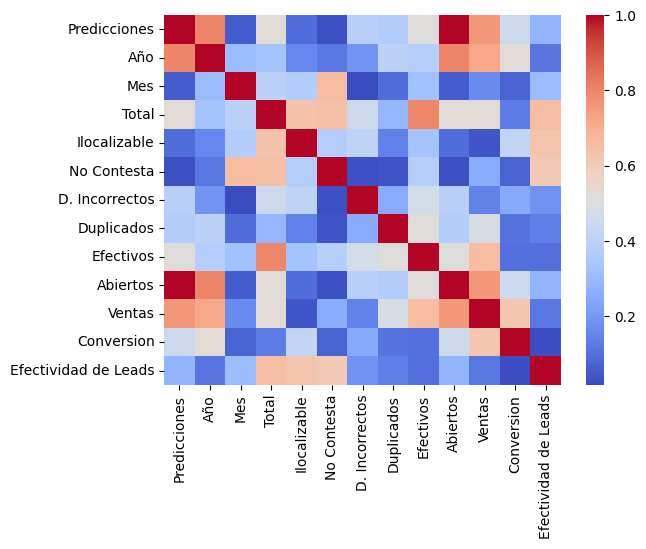

In [ ]:
#Graficamos el mapa de calor de los coeficientes de correlación
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')
Heat_Map

<Axes: >

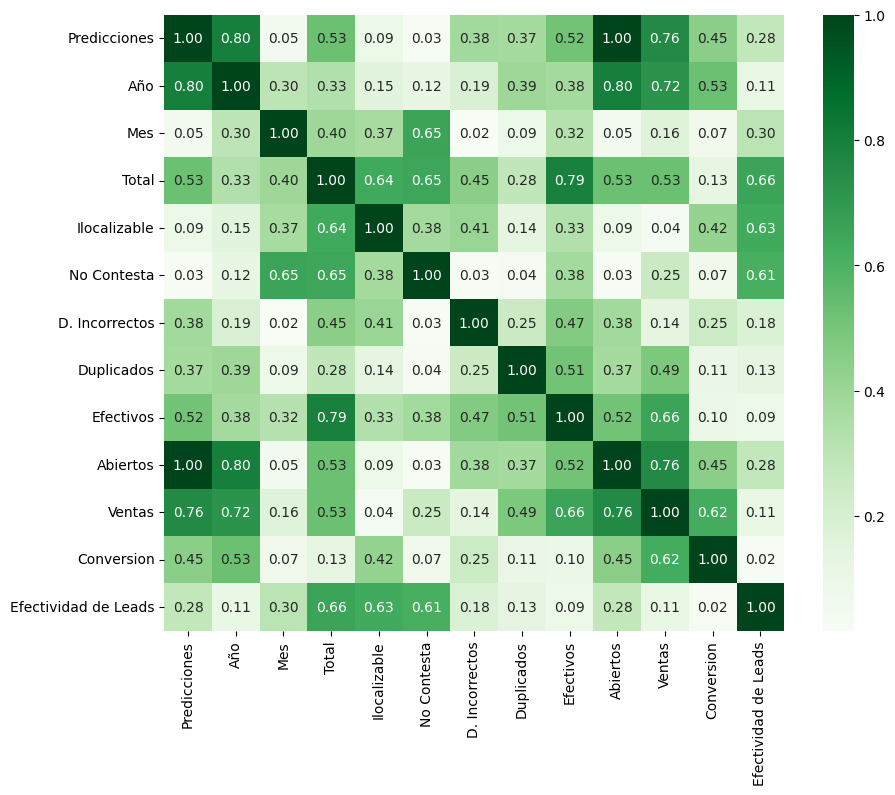

In [ ]:
#Ajustamos el mapa de calor de los coeficientes de correlación
plt.figure(figsize=(10,8))
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Greens', annot=True, fmt=".2f")
Heat_Map

In [ ]:
df['t'] = range(len(df))  # índice de tiempo: 0 = Ene 2024, ..., 28 = May 2026

In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

loo = LeaveOneOut()
candidatos = {
    'Abiertos (modelo anterior)': ['Abiertos'],
    'Total': ['Total'],
    'Efectivos': ['Efectivos'],
    'Total + t': ['Total', 't'],
    'Efectivos + t': ['Efectivos', 't'],
}

resultados = []
for nombre, feats in candidatos.items():
    X = df[feats].values
    m = LinearRegression().fit(X, Var_Dep)
    r2_muestra = m.score(X, Var_Dep)
    preds_loo = cross_val_predict(LinearRegression(), X, Var_Dep, cv=loo)
    r2_loo = r2_score(Var_Dep, preds_loo)
    mae_loo = mean_absolute_error(Var_Dep, preds_loo)
    resultados.append({'Modelo': nombre, 'R2 (muestra)': round(r2_muestra, 3),
                        'R2 (LOOCV)': round(r2_loo, 3), 'MAE (LOOCV)': round(mae_loo, 2)})

pd.DataFrame(resultados)

,Modelo,R2 (muestra),R2 (LOOCV),MAE (LOOCV)
0,Abiertos (modelo anterior),0.572,0.491,6.35
1,Total,0.279,0.158,8.08
2,Efectivos,0.429,0.345,6.70
3,Total + t,0.686,0.602,5.52
4,Efectivos + t,0.739,0.663,4.78


Podemos ver que el modelo de Efectivos + t es el mejor modelo

In [ ]:
#Redefinimos las variables independiente y dependiente para el modelo final
Vars_Indep= df[['Efectivos', 't']]
Var_Dep= df['Ventas']

#Ajustamos el modelo final
model= LinearRegression()
model.fit(X=Vars_Indep, y=Var_Dep)
print('Coeficientes (Efectivos, t):', model.coef_)
print('Intercepto:', model.intercept_)

Coeficientes (Efectivos, t): [0.01836172 0.83819314]
Intercepto: 3.0467870256314313


In [ ]:
#Evaluamos el modelo final: R2 dentro de la muestra y por LOOCV
coef_Deter = model.score(Vars_Indep, Var_Dep)
preds_loo_final = cross_val_predict(LinearRegression(), Vars_Indep, Var_Dep, cv=loo)
coef_Deter_loo = r2_score(Var_Dep, preds_loo_final)
coef_Correl = np.sqrt(coef_Deter)

print('R2 dentro de la muestra:', round(coef_Deter, 3))
print('R2 LOOCV (más honesto para datos nuevos):', round(coef_Deter_loo, 3))
print('Coeficiente de correlación:', round(coef_Correl, 3))

R2 dentro de la muestra: 0.739
R2 LOOCV (más honesto para datos nuevos): 0.663
Coeficiente de correlación: 0.86


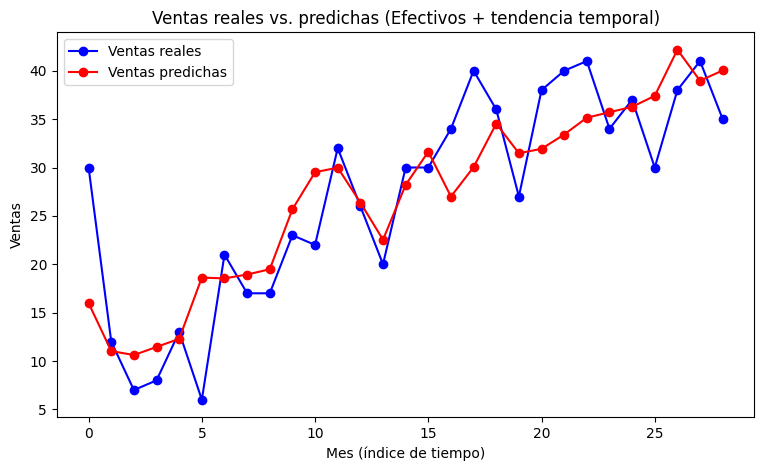

In [ ]:
#Predecimos y comparamos Ventas reales vs. predichas por el modelo final
y_pred = model.predict(X=Vars_Indep)

if 'Predicciones' in df.columns:
    df = df.drop(columns=['Predicciones'])
df.insert(0, 'Predicciones', y_pred)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df['t'], df['Ventas'], marker='o', color='blue', label='Ventas reales')
ax.plot(df['t'], df['Predicciones'], marker='o', color='red', label='Ventas predichas')
ax.set_xlabel('Mes (índice de tiempo)')
ax.set_ylabel('Ventas')
ax.set_title('Ventas reales vs. predichas (Efectivos + tendencia temporal)')
ax.legend()
plt.show()

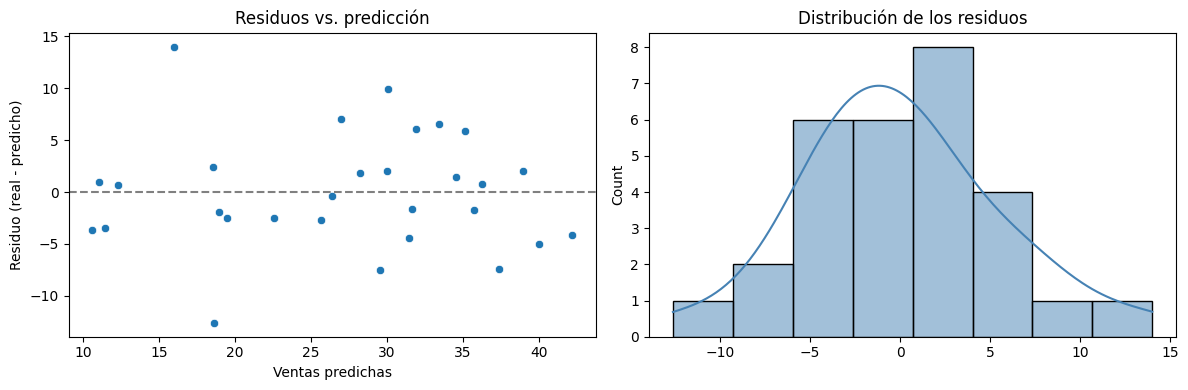

In [ ]:
#Revisamos los residuos del modelo para detectar patrones no capturados (heterocedasticidad, curvatura)
residuos = df['Ventas'] - df['Predicciones']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df['Predicciones'], y=residuos, ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Ventas predichas')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos vs. predicción')

sns.histplot(residuos, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribución de los residuos')
plt.tight_layout()
plt.show()